In [ ]:
import pandas as pd


df = pd.read_csv("/app/data/Data/full_data_table.csv", index_col=0)
df.head()

# delete this

: 

# Gene selection

In [3]:
gene_data_cols = [c for c in df.columns if c.startswith("Func_") or c in ["TMB_Count", "TMB_Value"]]

gene_data = df[gene_data_cols + ["class_labels"]].copy()

print("gene feature columns:", len(gene_data_cols))
print(gene_data_cols)

gene_data.head()

gene feature columns: 166
['Func_MSR1', 'Func_MUC4', 'Func_PTEN', 'Func_VHL', 'Func_CERCAM', 'Func_PBRM1', 'Func_PLEKHA2', 'Func_SETD2', 'Func_CD300E', 'Func_ANKRD36', 'Func_BAP1', 'Func_CHIT1', 'Func_ZNF304', 'Func_ARID1A', 'Func_GRIN3B', 'Func_NREP', 'Func_SYT15', 'Func_TXLNA', 'Func_ARHGEF25', 'Func_CCNB2', 'Func_SERPINB13', 'Func_PCK1', 'Func_FMN2', 'Func_LCN1', 'Func_MTOR', 'Func_ANKRD12', 'Func_OR4M2', 'Func_PIK3CA', 'Func_POC1B', 'Func_YLPM1', 'Func_AGAP6', 'Func_COL6A6', 'Func_KMT2C', 'Func_L1TD1', 'Func_TFDP2', 'Func_DIXDC1', 'Func_MAK16', 'Func_CPLX2', 'Func_IPP', 'Func_KRTAP4-9', 'Func_COL5A3', 'Func_PDE4C', 'Func_GATA2', 'Func_KDM5C', 'Func_KRTAP5-5', 'Func_MCPH1', 'Func_PABPC3', 'Func_RALGAPA1', 'Func_MSLNL', 'Func_PABPC1', 'Func_OR2T35', 'Func_RHEB', 'Func_DPPA2', 'Func_NEFH', 'Func_BTNL3', 'Func_C1orf52', 'Func_HLA-DRB5', 'Func_CRIPAK', 'Func_OVGP1', 'Func_TMEM255B', 'Func_MAP2K3', 'Func_POTED', 'Func_TRIP12', 'Func_ATM', 'Func_GINS3', 'Func_DHX37', 'Func_MAP7D1', 'Func_

,Func_MSR1,Func_MUC4,Func_PTEN,Func_VHL,Func_CERCAM,Func_PBRM1,Func_PLEKHA2,Func_SETD2,Func_CD300E,Func_ANKRD36,...,Func_VCX2,Func_MAX,Func_HIST1H2BM,Func_EME2,Func_CELA1,Func_FRG2B,Func_GPRC6A,TMB_Count,TMB_Value,class_labels
TCGA-A3-3311,WT,WT,WT,WT,WT,WT,LOF,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,57,0.000002,NON_ccA/B
TCGA-A3-3316,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,43,0.000002,ccB_only
TCGA-A3-3317,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,61,0.000002,ccB_only
TCGA-A3-3320,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,75,0.000003,ccA_only
TCGA-A3-3322,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,48,0.000002,ccA_only


## All gene data

In [4]:
# ML model replicate from 02_ml_model.R on gene_data
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score

# Encode Func_ columns as binary (WT=0, LOF=1) if string
func_cols = [c for c in gene_data_cols if c.startswith("Func_")]

gene_data_mod = gene_data.copy()
for c in func_cols:
    gene_data_mod[c] = gene_data_mod[c].map({"WT":0, "LOF":1})

# handle possible missing values - drop or fill
gene_data_mod = gene_data_mod.dropna()

X = gene_data_mod[gene_data_cols]
y = gene_data_mod["class_labels"].astype(str)

# new multiclass target values
allowed_labels = ['NON_ccA/B', 'ccB_only', 'ccA_only', 'SHARED_ccA/B']
if not set(y.unique()).issubset(set(allowed_labels)):
    raise ValueError(f"Unexpected class_labels values: {set(y.unique()) - set(allowed_labels)}")

print("class distribution:", y.value_counts(normalize=True).to_dict())

# stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

# 10-fold stratified CV on training data
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)

cv_logit_acc = []
cv_logit_mse = []
cv_rf_acc = []
cv_rf_mse = []

all_logit_probs = []
all_logit_obs = []
all_rf_probs = []
all_rf_obs = []

for fold_i, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # logistic (multiclass)
    logit = LogisticRegression(max_iter=1000, random_state=123, multi_class='multinomial', solver='lbfgs')
    logit.fit(X_tr, y_tr)
    logit_preds = logit.predict(X_val)

    cv_logit_acc.append(accuracy_score(y_val, logit_preds))

    # random forest (multiclass)
    rf = RandomForestClassifier(n_estimators=200, random_state=123)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_val)

    cv_rf_acc.append(accuracy_score(y_val, rf_preds))

    # store folded predictions for multiclass AUC (one-vs-rest)
    logit_probs = logit.predict_proba(X_val)
    rf_probs = rf.predict_proba(X_val)
    all_logit_obs.extend(y_val.tolist())
    all_rf_obs.extend(y_val.tolist())
    all_logit_probs.extend(logit_probs)
    all_rf_probs.extend(rf_probs)


from sklearn.preprocessing import label_binarize

# Summaries (multiclass accuracy)
print("Logit CV acc", sum(cv_logit_acc)/len(cv_logit_acc))
print("RF CV acc", sum(cv_rf_acc)/len(cv_rf_acc))

# multiclass AUC using one-vs-rest macro-average
y_bin = label_binarize(all_logit_obs, classes=allowed_labels)
logit_auc = roc_auc_score(y_bin, all_logit_probs, average='macro', multi_class='ovr')
rf_auc = roc_auc_score(y_bin, all_rf_probs, average='macro', multi_class='ovr')
print("Logit CV AUC (macro OVR)", logit_auc)
print("RF CV AUC (macro OVR)", rf_auc)

# final train/test evaluation
final_logit = LogisticRegression(max_iter=1000, random_state=123, multi_class='multinomial', solver='lbfgs')
final_logit.fit(X_train, y_train)
test_logit_preds = final_logit.predict(X_test)
print("Test Logit acc", accuracy_score(y_test, test_logit_preds))

final_rf = RandomForestClassifier(n_estimators=200, random_state=123)
final_rf.fit(X_train, y_train)
test_rf_preds = final_rf.predict(X_test)
print("Test RF acc", accuracy_score(y_test, test_rf_preds))

class distribution: {'ccB_only': 0.4179566563467492, 'ccA_only': 0.4117647058823529, 'SHARED_ccA/B': 0.08978328173374613, 'NON_ccA/B': 0.0804953560371517}
Logit CV acc 0.49230769230769234
RF CV acc 0.484
Logit CV AUC (macro OVR) 0.5207501912814707
RF CV AUC (macro OVR) 0.6046562456334766
Test Logit acc 0.5846153846153846
Test RF acc 0.3384615384615385


## Subset of genes from R scripts

In [5]:
# Repeat the model training process using the 21 selected features
selected_features = [
    "TMB_Count",
    "Func_MEGF6",
    "Func_ATG7",
    "Func_POLDIP2",
    "Func_COL5A3",
    "Func_MSLNL",
    "Func_SERPINB13",
    "Func_ST8SIA4",
    "Func_OR2T35",
    "Func_CHIT1",
    "Func_CASP5",
    "Func_TAS2R50",
    "Func_HOXC8",
    "Func_ARHGAP5",
    "Func_ANKRD36",
    "Func_SYT15",
    "Func_FAM209A",
    "Func_VCX3B",
    "Func_PTPRK",
    "Func_GATA2",
    "Func_CACYBP",
]

fs_data = df[selected_features + ["class_labels"]].copy()
for c in selected_features:
    if c.startswith("Func_"):
        fs_data[c] = fs_data[c].map({"WT": 0, "LOF": 1})

fs_data = fs_data.dropna()
X_fs = fs_data[selected_features]
y_fs = fs_data["class_labels"].astype(str)

allowed_labels = ['NON_ccA/B', 'ccB_only', 'ccA_only', 'SHARED_ccA/B']
if not set(y_fs.unique()).issubset(set(allowed_labels)):
    raise ValueError(f"Unexpected class_labels values: {set(y_fs.unique()) - set(allowed_labels)}")

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, stratify=y_fs, random_state=123
)

n_splits = 10
skf_fs = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)

cv_logit_acc_fs = []
cv_rf_acc_fs = []
all_logit_probs_fs = []
all_logit_obs_fs = []
all_rf_probs_fs = []
all_rf_obs_fs = []

for fold_i, (train_idx, val_idx) in enumerate(skf_fs.split(X_train_fs, y_train_fs), 1):
    X_tr, X_val = X_train_fs.iloc[train_idx], X_train_fs.iloc[val_idx]
    y_tr, y_val = y_train_fs.iloc[train_idx], y_train_fs.iloc[val_idx]

    logit_fs = LogisticRegression(max_iter=1000, random_state=123, multi_class='multinomial', solver='lbfgs')
    logit_fs.fit(X_tr, y_tr)
    logit_preds_fs = logit_fs.predict(X_val)
    cv_logit_acc_fs.append(accuracy_score(y_val, logit_preds_fs))

    rf_fs = RandomForestClassifier(n_estimators=200, random_state=123)
    rf_fs.fit(X_tr, y_tr)
    rf_preds_fs = rf_fs.predict(X_val)
    cv_rf_acc_fs.append(accuracy_score(y_val, rf_preds_fs))

    logit_probs_fs = logit_fs.predict_proba(X_val)
    rf_probs_fs = rf_fs.predict_proba(X_val)
    all_logit_obs_fs.extend(y_val.tolist())
    all_rf_obs_fs.extend(y_val.tolist())
    all_logit_probs_fs.extend(logit_probs_fs)
    all_rf_probs_fs.extend(rf_probs_fs)

from sklearn.preprocessing import label_binarize

print("Selected-features Logit CV acc", sum(cv_logit_acc_fs) / len(cv_logit_acc_fs))
print("Selected-features RF CV acc", sum(cv_rf_acc_fs) / len(cv_rf_acc_fs))

y_bin_fs = label_binarize(all_logit_obs_fs, classes=allowed_labels)
logit_auc_fs = roc_auc_score(y_bin_fs, all_logit_probs_fs, average='macro', multi_class='ovr')
rf_auc_fs = roc_auc_score(y_bin_fs, all_rf_probs_fs, average='macro', multi_class='ovr')
print("Selected-features Logit CV AUC (macro OVR)", logit_auc_fs)
print("Selected-features RF CV AUC (macro OVR)", rf_auc_fs)

final_logit_fs = LogisticRegression(max_iter=1000, random_state=123, multi_class='multinomial', solver='lbfgs')
final_logit_fs.fit(X_train_fs, y_train_fs)
print("Selected-features Test Logit acc", accuracy_score(y_test_fs, final_logit_fs.predict(X_test_fs)))

final_rf_fs = RandomForestClassifier(n_estimators=200, random_state=123)
final_rf_fs.fit(X_train_fs, y_train_fs)
print("Selected-features Test RF acc", accuracy_score(y_test_fs, final_rf_fs.predict(X_test_fs)))

Selected-features Logit CV acc 0.4187692307692307
Selected-features RF CV acc 0.434
Selected-features Logit CV AUC (macro OVR) 0.50983230351209
Selected-features RF CV AUC (macro OVR) 0.4481136036904081
Selected-features Test Logit acc 0.5230769230769231
Selected-features Test RF acc 0.3384615384615385


## Feature selection using new class_labels data

In [6]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Leakage-safe setup: create one outer split and rank features using training data only
X_all = gene_data_mod[gene_data_cols]
y_all = gene_data_mod["class_labels"].astype(str)

X_outer_train, X_outer_test, y_outer_train, y_outer_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=123,
 )

y_train_enc = LabelEncoder().fit_transform(y_outer_train)

feature_count = min(50, X_outer_train.shape[1])
relevance = mutual_info_classif(
    X_outer_train,
    y_train_enc,
    discrete_features='auto',
    random_state=123,
 )
relevance = pd.Series(relevance, index=X_outer_train.columns)

# Pairwise redundancy between features on outer-train only
redundancy = pd.DataFrame(
    np.zeros((X_outer_train.shape[1], X_outer_train.shape[1])),
    index=X_outer_train.columns,
    columns=X_outer_train.columns,
 )
for col in X_outer_train.columns:
    mi = mutual_info_regression(
        X_outer_train,
        X_outer_train[col],
        discrete_features='auto',
        random_state=123,
    )
    redundancy.loc[:, col] = mi

selected = []
remaining = list(X_outer_train.columns)
if remaining:
    first = relevance.idxmax()
    selected.append(first)
    remaining.remove(first)

while len(selected) < feature_count and remaining:
    weighted_scores = {}
    for col in remaining:
        red = redundancy.loc[col, selected].mean() if selected else 0
        weighted_scores[col] = relevance[col] - red
    best = max(weighted_scores, key=weighted_scores.get)
    selected.append(best)
    remaining.remove(best)

selected_mrmr_features = selected
print("mRMR-style selected features (top", feature_count, ") from outer-train split:")
print(selected_mrmr_features)
print(f"Outer-train shape: {X_outer_train.shape}, outer-test shape: {X_outer_test.shape}")


mRMR-style selected features (top 50 ) from outer-train split:
['Func_KRTAP4-9', 'Func_PRSS16', 'Func_OR5P2', 'Func_ARFGEF2', 'Func_BTNL3', 'Func_TMEM255B', 'Func_LCN1', 'Func_VHL', 'Func_NF2', 'Func_VCX2', 'Func_KMT2C', 'Func_PABPC3', 'Func_MAGEC1', 'Func_PABPC1', 'Func_KRTAP1-1', 'Func_SERPINB13', 'Func_SUCLG1', 'Func_PDE4C', 'Func_SLC22A9', 'Func_CERCAM', 'Func_TFDP2', 'Func_AGAP6', 'Func_PGPEP1L', 'Func_CDHR5', 'Func_TRIP12', 'Func_ANKRD12', 'Func_C1orf52', 'Func_MAP2K3', 'Func_CACYBP', 'Func_ATM', 'Func_ATG7', 'Func_RHEB', 'Func_GOT1', 'Func_ZNF717', 'Func_CASP5', 'Func_TCEB1', 'Func_OR2T35', 'Func_RALGAPA1', 'Func_CDH2', 'Func_DNAJC14', 'Func_POLDIP2', 'Func_WDR73', 'Func_ZNF800', 'Func_ETV4', 'Func_FOXD4L4', 'Func_CLRN3', 'Func_MAGEE1', 'Func_RAD52', 'Func_GINS3', 'Func_NEFH']
Outer-train shape: (258, 166), outer-test shape: (65, 166)


In [7]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
import numpy as np
import pandas as pd

# Build top-k results using leakage-safe mRMR ranking from outer-train only
try:
    selected_mrmr_features
    X_outer_train
    X_outer_test
    y_outer_train
    y_outer_test
except NameError:
    X_all = gene_data_mod[gene_data_cols]
    y_all = gene_data_mod["class_labels"].astype(str)

    X_outer_train, X_outer_test, y_outer_train, y_outer_test = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=123,
    )

    y_train_enc = LabelEncoder().fit_transform(y_outer_train)
    feature_count = min(50, X_outer_train.shape[1])
    relevance = mutual_info_classif(
        X_outer_train,
        y_train_enc,
        discrete_features='auto',
        random_state=123,
    )
    relevance = pd.Series(relevance, index=X_outer_train.columns)

    redundancy = pd.DataFrame(
        np.zeros((X_outer_train.shape[1], X_outer_train.shape[1])),
        index=X_outer_train.columns,
        columns=X_outer_train.columns,
    )
    for col in X_outer_train.columns:
        redundancy.loc[:, col] = mutual_info_regression(
            X_outer_train,
            X_outer_train[col],
            discrete_features='auto',
            random_state=123,
        )

    selected_mrmr_features = []
    remaining = list(X_outer_train.columns)
    if remaining:
        first = relevance.idxmax()
        selected_mrmr_features.append(first)
        remaining.remove(first)

    while len(selected_mrmr_features) < feature_count and remaining:
        scores = {
            col: relevance[col]
            - redundancy.loc[col, selected_mrmr_features].mean()
            for col in remaining
        }
        best = max(scores, key=scores.get)
        selected_mrmr_features.append(best)
        remaining.remove(best)

results = []
for k in range(1, len(selected_mrmr_features) + 1):
    features_k = selected_mrmr_features[:k]
    X_train_k = X_outer_train[features_k]
    y_train_k = y_outer_train
    X_test_k = X_outer_test[features_k]
    y_test_k = y_outer_test

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
    logit_f1_scores = []
    rf_f1_scores = []
    all_logit_probs = []
    all_rf_probs = []
    all_obs = []

    for train_idx, val_idx in skf.split(X_train_k, y_train_k):
        X_tr = X_train_k.iloc[train_idx]
        X_val = X_train_k.iloc[val_idx]
        y_tr = y_train_k.iloc[train_idx]
        y_val = y_train_k.iloc[val_idx]

        logit = LogisticRegression(
            max_iter=1000,
            random_state=123,
            multi_class='multinomial',
            solver='lbfgs',
        )
        logit.fit(X_tr, y_tr)
        y_pred_logit = logit.predict(X_val)
        logit_f1_scores.append(f1_score(y_val, y_pred_logit, average='macro'))
        all_logit_probs.append(logit.predict_proba(X_val))

        rf = RandomForestClassifier(n_estimators=200, random_state=123)
        rf.fit(X_tr, y_tr)
        y_pred_rf = rf.predict(X_val)
        rf_f1_scores.append(f1_score(y_val, y_pred_rf, average='macro'))
        all_rf_probs.append(rf.predict_proba(X_val))

        all_obs.extend(y_val.tolist())

    all_logit_probs = np.vstack(all_logit_probs)
    all_rf_probs = np.vstack(all_rf_probs)
    all_obs = np.array(all_obs)
    classes = sorted(np.unique(y_train_k))
    y_bin = label_binarize(all_obs, classes=classes)

    logit_auc = roc_auc_score(
        y_bin,
        all_logit_probs,
        average='macro',
        multi_class='ovr',
    )
    rf_auc = roc_auc_score(
        y_bin,
        all_rf_probs,
        average='macro',
        multi_class='ovr',
    )

    results.append(
        {
            'k': k,
            'logit_f1': np.mean(logit_f1_scores),
            'logit_auc': logit_auc,
            'rf_f1': np.mean(rf_f1_scores),
            'rf_auc': rf_auc,
        }
    )

results_df = pd.DataFrame(results)

best_logit_f1_idx = results_df['logit_f1'].idxmax()
best_logit_auc_idx = results_df['logit_auc'].idxmax()
best_rf_f1_idx = results_df['rf_f1'].idxmax()
best_rf_auc_idx = results_df['rf_auc'].idxmax()

print(
    f"Best Logistic F1: k={int(results_df.loc[best_logit_f1_idx, 'k'])}, "
    f"score={results_df.loc[best_logit_f1_idx, 'logit_f1']:.4f}"
)
print(
    f"Best Logistic AUC: k={int(results_df.loc[best_logit_auc_idx, 'k'])}, "
    f"score={results_df.loc[best_logit_auc_idx, 'logit_auc']:.4f}"
)
print(
    f"Best RF F1: k={int(results_df.loc[best_rf_f1_idx, 'k'])}, "
    f"score={results_df.loc[best_rf_f1_idx, 'rf_f1']:.4f}"
)
print(
    f"Best RF AUC: k={int(results_df.loc[best_rf_auc_idx, 'k'])}, "
    f"score={results_df.loc[best_rf_auc_idx, 'rf_auc']:.4f}"
)

# Optional holdout test metrics at the k selected by each metric
def evaluate_on_holdout(features):
    X_tr = X_outer_train[features]
    X_te = X_outer_test[features]

    logit = LogisticRegression(
        max_iter=1000,
        random_state=123,
        multi_class='multinomial',
        solver='lbfgs',
    )
    logit.fit(X_tr, y_outer_train)
    logit_pred = logit.predict(X_te)
    logit_f1 = f1_score(y_outer_test, logit_pred, average='macro')
    logit_auc = roc_auc_score(
        label_binarize(y_outer_test, classes=sorted(np.unique(y_outer_train))),
        logit.predict_proba(X_te),
        average='macro',
        multi_class='ovr',
    )

    rf = RandomForestClassifier(n_estimators=200, random_state=123)
    rf.fit(X_tr, y_outer_train)
    rf_pred = rf.predict(X_te)
    rf_f1 = f1_score(y_outer_test, rf_pred, average='macro')
    rf_auc = roc_auc_score(
        label_binarize(y_outer_test, classes=sorted(np.unique(y_outer_train))),
        rf.predict_proba(X_te),
        average='macro',
        multi_class='ovr',
    )
    return logit_f1, logit_auc, rf_f1, rf_auc

k_logit_f1 = int(results_df.loc[best_logit_f1_idx, 'k'])
k_logit_auc = int(results_df.loc[best_logit_auc_idx, 'k'])
k_rf_f1 = int(results_df.loc[best_rf_f1_idx, 'k'])
k_rf_auc = int(results_df.loc[best_rf_auc_idx, 'k'])

print("\nHoldout test metrics at selected k values:")
lf1, lauc, rf1, rauc = evaluate_on_holdout(selected_mrmr_features[:k_logit_f1])
print(f"Using k={k_logit_f1} (best by Logistic F1 criterion) -> Logit F1={lf1:.4f}, Logit AUC={lauc:.4f}, RF F1={rf1:.4f}, RF AUC={rauc:.4f}")
lf1, lauc, rf1, rauc = evaluate_on_holdout(selected_mrmr_features[:k_logit_auc])
print(f"Using k={k_logit_auc} (best by Logistic AUC criterion) -> Logit F1={lf1:.4f}, Logit AUC={lauc:.4f}, RF F1={rf1:.4f}, RF AUC={rauc:.4f}")
lf1, lauc, rf1, rauc = evaluate_on_holdout(selected_mrmr_features[:k_rf_f1])
print(f"Using k={k_rf_f1} (best by RF F1 criterion) -> Logit F1={lf1:.4f}, Logit AUC={lauc:.4f}, RF F1={rf1:.4f}, RF AUC={rauc:.4f}")
lf1, lauc, rf1, rauc = evaluate_on_holdout(selected_mrmr_features[:k_rf_auc])
print(f"Using k={k_rf_auc} (best by RF AUC criterion) -> Logit F1={lf1:.4f}, Logit AUC={lauc:.4f}, RF F1={rf1:.4f}, RF AUC={rauc:.4f}")

Best Logistic F1: k=8, score=0.2721
Best Logistic AUC: k=10, score=0.4803
Best RF F1: k=8, score=0.2706
Best RF AUC: k=10, score=0.4861

Holdout test metrics at selected k values:
Using k=8 (best by Logistic F1 criterion) -> Logit F1=0.2173, Logit AUC=0.5009, RF F1=0.2173, RF AUC=0.5017
Using k=10 (best by Logistic AUC criterion) -> Logit F1=0.2173, Logit AUC=0.5009, RF F1=0.2173, RF AUC=0.5009
Using k=8 (best by RF F1 criterion) -> Logit F1=0.2173, Logit AUC=0.5009, RF F1=0.2173, RF AUC=0.5017
Using k=10 (best by RF AUC criterion) -> Logit F1=0.2173, Logit AUC=0.5009, RF F1=0.2173, RF AUC=0.5009


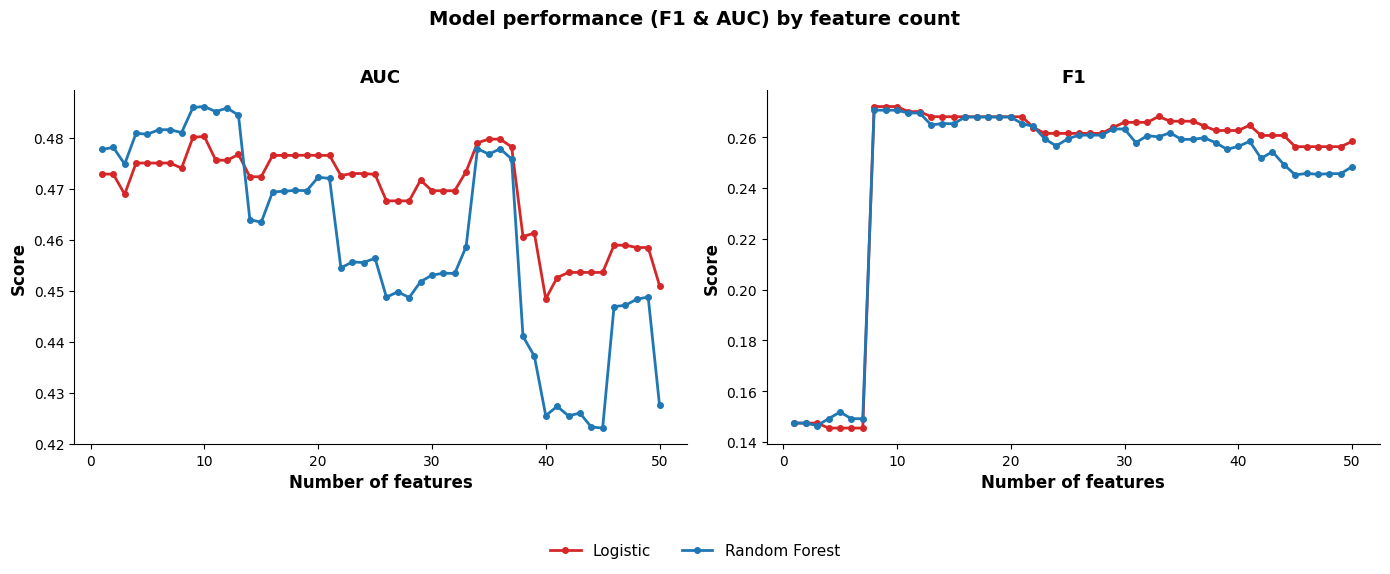

In [8]:
import matplotlib.pyplot as plt

# Prepare data for plotting
results_long = results_df.melt(
    id_vars=['k'],
    value_vars=['logit_f1', 'logit_auc', 'rf_f1', 'rf_auc'],
    var_name='metric_model',
    value_name='score'
)
results_long[['model', 'metric']] = results_long['metric_model'].str.split('_', expand=True)
results_long['model'] = results_long['model'].map({'logit': 'Logistic', 'rf': 'Random Forest'})
results_long['metric'] = results_long['metric'].str.upper()

# Create figure with two subplots (AUC and F1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic': '#d62728', 'Random Forest': '#1f77b4'}  # Red and Blue

for ax, metric in zip(axes, ['AUC', 'F1']):
    data_subset = results_long[results_long['metric'] == metric]
    
    for model in ['Logistic', 'Random Forest']:
        model_data = data_subset[data_subset['model'] == model]
        ax.plot(
            model_data['k'],
            model_data['score'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=model,
            color=colors[model]
        )
    
    ax.set_xlabel('Number of features', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.grid(False)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add legend
fig.legend(
    ['Logistic', 'Random Forest'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=11,
    frameon=False
)

fig.suptitle('Model performance (F1 & AUC) by feature count', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


# Top-10 genes + metadata + WSI array

Fit a multinomial logistic regression model using:

- top 10 selected genes
- patient metadata columns ('Split' removed)
- expanded WSI array values

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

metadata_columns = [
    'gender',
    'age_diag',
    'grade',
    'cancer_history',
    'ajcc_path_tumor_pt',
    'ajcc_path_nodes_pn',
    'ajcc_clin_metastasis_cm',
    'ajcc_path_metastasis_pm',
    'ajcc_path_tumor_stage',
    'vital_status_12',
    'race_Asian',
    'race_Black or African American',
    'race_Hispanic or Latino',
    'race_White',
    'race_other',
    'VHL_mutation',
    'PBMR1_mutation',
    'TTN_mutation',
]

wsi_feature_dir = Path('/app/data/Data/Features/WSI Features')
gene_k = 10
gene_columns_top10 = selected_mrmr_features[:gene_k]
required_columns = gene_columns_top10 + metadata_columns + ['chosen_exam', 'class_labels']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f'Missing expected columns: {missing_columns}')


def load_wsi_embedding(npz_name):
    npz_path = wsi_feature_dir / npz_name
    if not npz_path.exists():
        return None

    with np.load(npz_path) as data:
        embedding = np.ravel(data['arr_0']).astype(float)
    return embedding


model_df = df[required_columns].copy()
for col in gene_columns_top10:
    if col.startswith('Func_'):
        model_df[col] = model_df[col].map({'WT': 0, 'LOF': 1})

model_df['wsi_embedding'] = model_df['chosen_exam'].apply(load_wsi_embedding)
model_df = model_df.dropna(subset=['class_labels', 'wsi_embedding']).copy()

embedding_lengths = model_df['wsi_embedding'].apply(len)
if embedding_lengths.nunique() != 1:
    raise ValueError(
        f'WSI embedding lengths are inconsistent: {embedding_lengths.value_counts().to_dict()}'
    )

wsi_array_df = pd.DataFrame(
    model_df['wsi_embedding'].tolist(),
    index=model_df.index,
).add_prefix('wsi_')

metadata_df = model_df[metadata_columns].apply(pd.to_numeric, errors='coerce')
gene_df = model_df[gene_columns_top10].apply(pd.to_numeric, errors='coerce')

raw_feature_df = pd.concat([gene_df, metadata_df, wsi_array_df], axis=1)
y_multimodal = model_df['class_labels'].astype(str)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    raw_feature_df,
    y_multimodal,
    test_size=0.2,
    stratify=y_multimodal,
    random_state=123,
)

logit_multi = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        (
            'model',
            LogisticRegression(
                max_iter=2000,
                random_state=123,
                multi_class='multinomial',
                solver='lbfgs',
            ),
        ),
    ]
)

skf_multi = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_f1_scores_multi = []
all_probs_multi = []
all_obs_multi = []

for train_idx, val_idx in skf_multi.split(X_train_multi, y_train_multi):
    X_tr = X_train_multi.iloc[train_idx]
    X_val = X_train_multi.iloc[val_idx]
    y_tr = y_train_multi.iloc[train_idx]
    y_val = y_train_multi.iloc[val_idx]

    logit_multi.fit(X_tr, y_tr)
    y_pred_multi = logit_multi.predict(X_val)

    cv_f1_scores_multi.append(f1_score(y_val, y_pred_multi, average='macro'))
    all_probs_multi.append(logit_multi.predict_proba(X_val))
    all_obs_multi.extend(y_val.tolist())

all_probs_multi = np.vstack(all_probs_multi)
classes_multi = sorted(np.unique(y_train_multi))
y_bin_multi = label_binarize(all_obs_multi, classes=classes_multi)
cv_auc_multi = roc_auc_score(
    y_bin_multi,
    all_probs_multi,
    average='macro',
    multi_class='ovr',
)

logit_multi.fit(X_train_multi, y_train_multi)
y_test_pred_multi = logit_multi.predict(X_test_multi)
y_test_prob_multi = logit_multi.predict_proba(X_test_multi)
y_test_bin_multi = label_binarize(y_test_multi, classes=classes_multi)

feature_names_multi = raw_feature_df.columns.tolist()
metadata_feature_names = metadata_columns.copy()
wsi_feature_names = wsi_array_df.columns.tolist()

missing_wsi_files = int(model_df['wsi_embedding'].isna().sum())

top10_multimodal_results = pd.Series(
    {
        'n_samples': len(raw_feature_df),
        'n_features_total_after_preprocessing': len(feature_names_multi),
        'n_gene_features': len(gene_columns_top10),
        'n_metadata_features_after_preprocessing': len(metadata_feature_names),
        'n_wsi_features': len(wsi_feature_names),
        'cv_macro_f1': np.mean(cv_f1_scores_multi),
        'cv_macro_ovr_auc': cv_auc_multi,
        'test_accuracy': accuracy_score(y_test_multi, y_test_pred_multi),
        'test_macro_f1': f1_score(y_test_multi, y_test_pred_multi, average='macro'),
        'test_macro_ovr_auc': roc_auc_score(
            y_test_bin_multi,
            y_test_prob_multi,
            average='macro',
            multi_class='ovr',
        ),
    }
)

print('Top-10 genes:', gene_columns_top10)
print('WSI embedding length:', wsi_array_df.shape[1])
print('Missing WSI files:', missing_wsi_files)
print('\nMultimodal logistic results:')

top10_multimodal_results

Top-10 genes: ['Func_KRTAP4-9', 'Func_PRSS16', 'Func_OR5P2', 'Func_ARFGEF2', 'Func_BTNL3', 'Func_TMEM255B', 'Func_LCN1', 'Func_VHL', 'Func_NF2', 'Func_VCX2']
WSI embedding length: 1024
Missing WSI files: 0

Multimodal logistic results:


n_samples                                   323.000000
n_features_total_after_preprocessing       1052.000000
n_gene_features                              10.000000
n_metadata_features_after_preprocessing      18.000000
n_wsi_features                             1024.000000
cv_macro_f1                                   0.322863
cv_macro_ovr_auc                              0.615898
test_accuracy                                 0.492308
test_macro_f1                                 0.340545
test_macro_ovr_auc                            0.571161
dtype: float64